# VGGT — Visual Geometry Grounded Transformer (Colab)

Run [VGGT](https://github.com/facebookresearch/vggt) in Google Colab to turn a handful of images (or a short video) into a **3D point cloud + camera poses**, exported as a `.glb` file you can open in any 3D viewer.

**Before you start:** switch to a GPU runtime (`Runtime → Change runtime type → GPU`, prefer T4/L4/A100). VGGT needs CUDA.

Pipeline:
1. Install dependencies + clone repo
2. Download the pretrained `VGGT-1B` checkpoint (auto-cached after first run)
3. Provide input images (upload, video, or built-in example)
4. Run feed-forward inference (typically <1 s on H100, a few seconds on T4)
5. Convert predictions → GLB scene (point cloud + camera frustums)
6. Preview inline + download the `.glb`

## 1. Verify GPU

In [1]:
!nvidia-smi

Fri Apr 24 18:26:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Clone the VGGT repo and install dependencies

Colab already ships with a recent PyTorch + CUDA, so we install VGGT's lightweight extras only (skip the pinned `torch==2.3.1` to avoid clobbering Colab's runtime).

In [2]:
%cd /content
![ -d vggt ] || git clone https://github.com/facebookresearch/vggt.git
%cd /content/vggt

/content
Cloning into 'vggt'...
remote: Enumerating objects: 1272, done.
remote: Counting objects: 100% (268/268), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 1272 (delta 209), reused 156 (delta 156), pack-reused 1004 (from 1)
Receiving objects: 100% (1272/1272), 64.83 MiB | 48.31 MiB/s, done.
Resolving deltas: 100% (639/639), done.
/content/vggt


In [3]:
# Core deps (skip torch/torchvision pin — keep Colab's CUDA-matched build)
!pip install -q numpy Pillow huggingface_hub einops safetensors
# Visualization deps for GLB export and point-cloud rendering
!pip install -q trimesh opencv-python scipy matplotlib requests
# (Optional) sky filtering uses onnxruntime
!pip install -q onnxruntimeglb_path

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 46.6 MB/s eta 0:00:00


In [4]:
# Make the repo importable
import sys, os
sys.path.insert(0, '/content/vggt')
os.chdir('/content/vggt')
print('Working dir:', os.getcwd())

Working dir: /content/vggt


## 3. Load the VGGT-1B model

First call downloads ~5 GB of weights from Hugging Face (cached afterwards). Use the `-Commercial` variant if you need commercial-use rights — see the README.

In [5]:
import torch
from vggt.models.vggt import VGGT

device = 'cuda' if torch.cuda.is_available() else 'cpu'
assert device == 'cuda', 'GPU runtime required — Runtime → Change runtime type → GPU'

# bfloat16 on Ampere+ (T4 is sm_75 → falls back to float16)
dtype = torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float16
print(f'Device: {device} | dtype: {dtype}')

print('Loading VGGT-1B (downloads on first run, ~5 GB)...')
model = VGGT.from_pretrained('facebook/VGGT-1B').to(device)
model.eval()
print('Model ready.')

Device: cuda | dtype: torch.float16
Loading VGGT-1B (downloads on first run, ~5 GB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.03G [00:00<?, ?B/s]

Model ready.


## 4. Provide input images

Pick **one** of the three options below and run that cell. All of them populate the folder `/content/scene/images/`.

### Option A — Upload your own images

In [ ]:
import os, shutil
from google.colab import files

scene_dir = '/content/scene'
img_dir = os.path.join(scene_dir, 'images')
if os.path.exists(scene_dir):
    shutil.rmtree(scene_dir)
os.makedirs(img_dir, exist_ok=True)

uploaded = files.upload()  # opens the file picker
for name, data in uploaded.items():
    with open(os.path.join(img_dir, name), 'wb') as f:
        f.write(data)
print(f'Saved {len(uploaded)} images to {img_dir}')

### Option B — Upload a short video (1 frame/sec is extracted)

In [ ]:
import os, shutil, cv2
from google.colab import files

scene_dir = '/content/scene'
img_dir = os.path.join(scene_dir, 'images')
if os.path.exists(scene_dir):
    shutil.rmtree(scene_dir)
os.makedirs(img_dir, exist_ok=True)

uploaded = files.upload()
video_path = next(iter(uploaded))  # take the first uploaded file
with open(video_path, 'wb') as f:
    f.write(uploaded[video_path])

FRAMES_PER_SECOND = 1   # bump this for denser sampling
vs = cv2.VideoCapture(video_path)
fps = vs.get(cv2.CAP_PROP_FPS) or 30
stride = max(1, int(fps / FRAMES_PER_SECOND))

saved, count = 0, 0
while True:
    ok, frame = vs.read()
    if not ok:
        break
    if count % stride == 0:
        cv2.imwrite(os.path.join(img_dir, f'{saved:06d}.png'), frame)
        saved += 1
    count += 1
vs.release()
print(f'Extracted {saved} frames into {img_dir} (input fps={fps:.1f})')

### Option C — Use a built-in example (kitchen scene shipped with the repo)

In [6]:
import os, shutil, glob

scene_dir = '/content/scene'
img_dir = os.path.join(scene_dir, 'images')
if os.path.exists(scene_dir):
    shutil.rmtree(scene_dir)
os.makedirs(img_dir, exist_ok=True)

src_dirs = [
    '/content/vggt/examples/kitchen/images',
    '/content/vggt/examples/room/images',
]
src = next((d for d in src_dirs if os.path.isdir(d) and glob.glob(os.path.join(d, '*'))), None)
if src is None:
    raise FileNotFoundError('No example images shipped with this checkout — use Option A or B.')

for p in sorted(glob.glob(os.path.join(src, '*'))):
    shutil.copy(p, img_dir)
print(f'Copied {len(os.listdir(img_dir))} images from {src}')

Copied 25 images from /content/vggt/examples/kitchen/images


## 5. Run VGGT inference

This is the actual 3D reconstruction. Output keys (after squeezing the batch dim):
- `pose_enc`, `extrinsic`, `intrinsic` — camera parameters
- `depth` `(S,H,W,1)`, `depth_conf` `(S,H,W)`
- `world_points` `(S,H,W,3)`, `world_points_conf` `(S,H,W)` — direct point-map prediction
- `world_points_from_depth` `(S,H,W,3)` — depth unprojected through cameras (often crisper)
- `images` — preprocessed input tensor (kept for visualization)

In [7]:
import glob, time, gc
import numpy as np
import torch
from vggt.utils.load_fn import load_and_preprocess_images
from vggt.utils.pose_enc import pose_encoding_to_extri_intri
from vggt.utils.geometry import unproject_depth_map_to_point_map

image_names = sorted(glob.glob(os.path.join(img_dir, '*')))
assert len(image_names) > 0, f'No images found in {img_dir}'
print(f'Loading {len(image_names)} images...')

images = load_and_preprocess_images(image_names).to(device)
print(f'Image batch shape: {tuple(images.shape)}  (S, 3, H, W)')

t0 = time.time()
with torch.no_grad():
    with torch.cuda.amp.autocast(dtype=dtype):
        predictions = model(images)
torch.cuda.synchronize()
print(f'VGGT forward pass: {time.time() - t0:.2f}s')

# Decode pose encoding into 3x4 extrinsics + 3x3 intrinsics (OpenCV convention)
extrinsic, intrinsic = pose_encoding_to_extri_intri(predictions['pose_enc'], images.shape[-2:])
predictions['extrinsic'] = extrinsic
predictions['intrinsic'] = intrinsic

# Move everything to NumPy and drop the batch dim
for k in list(predictions.keys()):
    if isinstance(predictions[k], torch.Tensor):
        predictions[k] = predictions[k].cpu().numpy().squeeze(0)
predictions['pose_enc_list'] = None

# Unproject depth -> world points (usually higher quality than the raw point head)
predictions['world_points_from_depth'] = unproject_depth_map_to_point_map(
    predictions['depth'], predictions['extrinsic'], predictions['intrinsic']
)

# Persist for later (and so you can re-render with different filters without re-running the model)
np.savez(os.path.join(scene_dir, 'predictions.npz'),
         **{k: v for k, v in predictions.items() if v is not None})

del images
gc.collect(); torch.cuda.empty_cache()
print('Predictions ready. Keys:', [k for k, v in predictions.items() if v is not None])

Loading 25 images...
Image batch shape: (25, 3, 350, 518)  (S, 3, H, W)


/tmp/ipykernel_3779/3573003841.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):
/content/vggt/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


VGGT forward pass: 11.74s
Predictions ready. Keys: ['pose_enc', 'depth', 'depth_conf', 'world_points', 'world_points_conf', 'images', 'extrinsic', 'intrinsic', 'world_points_from_depth']


## 6. Build the GLB 3D scene

Tunable knobs:
- `CONF_THRES` — drop the lowest *X%* of low-confidence points (0 = keep all, 50 = drop bottom half).
- `PREDICTION_MODE` — `'Depthmap and Camera Branch'` (recommended) or `'Pointmap Branch'`.
- `SHOW_CAM` — include camera frustums.
- `MASK_BLACK_BG` / `MASK_WHITE_BG` — drop near-black / near-white pixels (handy for object-on-background shots).

In [8]:
from visual_util import predictions_to_glb

CONF_THRES = 50.0
PREDICTION_MODE = 'Depthmap and Camera Branch'  # or 'Pointmap Branch'
SHOW_CAM = True
MASK_BLACK_BG = False
MASK_WHITE_BG = False
MASK_SKY = False  # set True for outdoor scenes (downloads skyseg.onnx on first use)

glb_path = os.path.join(scene_dir, 'scene.glb')
scene = predictions_to_glb(
    predictions,
    conf_thres=CONF_THRES,
    filter_by_frames='All',
    mask_black_bg=MASK_BLACK_BG,
    mask_white_bg=MASK_WHITE_BG,
    show_cam=SHOW_CAM,
    mask_sky=MASK_SKY,
    target_dir=scene_dir,
    prediction_mode=PREDICTION_MODE,
)
scene.export(file_obj=glb_path)
print(f'Exported: {glb_path}  ({os.path.getsize(glb_path)/1e6:.2f} MB)')

Building GLB scene
Using Depthmap and Camera Branch
GLB Scene built
Exported: /content/scene/scene.glb  (36.29 MB)


## 7. Quick inline preview (matplotlib)

Cheap orthographic preview of the point cloud, just to confirm the reconstruction looks reasonable. For real interactive viewing, download the GLB (next cell) and open it in https://gltf-viewer.donmccurdy.com or any 3D tool.

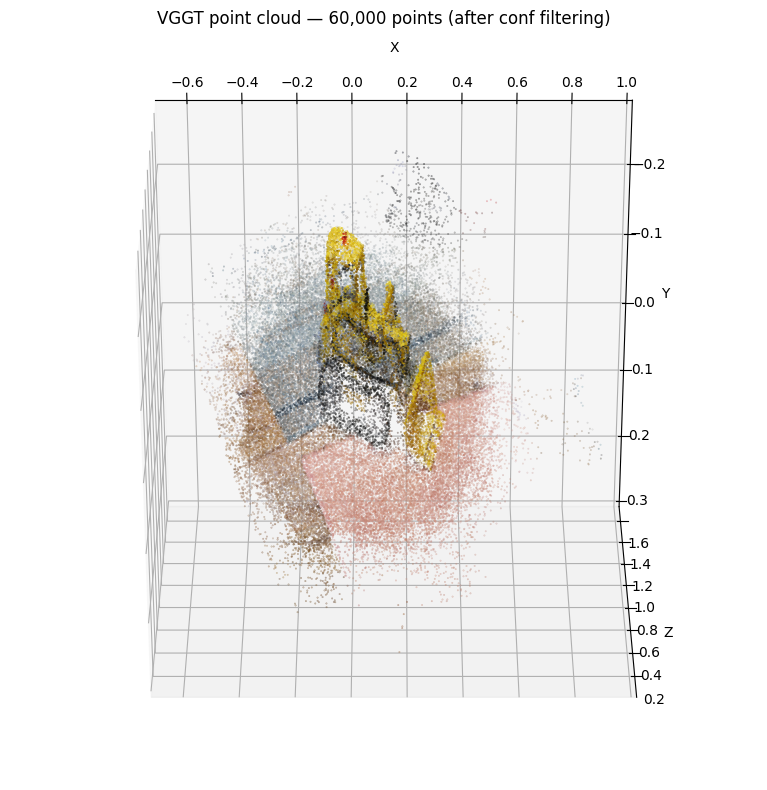

In [9]:
import numpy as np
import matplotlib.pyplot as plt

pts = predictions['world_points_from_depth'].reshape(-1, 3)
imgs = predictions['images']  # (S, 3, H, W)
cols = np.transpose(imgs, (0, 2, 3, 1)).reshape(-1, 3)
conf = predictions['depth_conf'].reshape(-1)

thr = np.percentile(conf, CONF_THRES) if CONF_THRES > 0 else 0.0
mask = (conf >= thr) & (conf > 1e-5)
pts_v, cols_v = pts[mask], np.clip(cols[mask], 0, 1)

# Subsample for plotting speed
if len(pts_v) > 60000:
    sel = np.random.choice(len(pts_v), 60000, replace=False)
    pts_v, cols_v = pts_v[sel], cols_v[sel]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts_v[:, 0], pts_v[:, 1], pts_v[:, 2], c=cols_v, s=0.5, marker='.')
ax.set_title(f'VGGT point cloud — {len(pts_v):,} points (after conf filtering)')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=-60, azim=-90)  # roughly looking through the first camera
plt.tight_layout()
plt.show()

## 8. Download the GLB

In [10]:
from google.colab import files
files.download(glb_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8b. Save the result to Google Drive (`MyDrive/3DGen/`)

Mounts your Drive and copies the GLB (plus `predictions.npz` and any COLMAP outputs that exist) into a timestamped subfolder under `MyDrive/3DGen/`. Re-running this cell creates a new timestamped subfolder, so previous saves are never overwritten.

The first run will pop up a Google auth prompt — accept it and the mount sticks for the rest of the runtime.

In [ ]:
import os, shutil, datetime
from google.colab import drive

# Mount Google Drive (idempotent — if already mounted, this is a no-op)
if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

# Destination: MyDrive/3DGen/<scene>_<timestamp>/
DRIVE_ROOT = '/content/drive/MyDrive/3DGen'
SCENE_NAME = 'scene'  # change this if you want a custom subfolder name
stamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
dst_dir = os.path.join(DRIVE_ROOT, f'{SCENE_NAME}_{stamp}')
os.makedirs(dst_dir, exist_ok=True)

# Always copy the GLB
shutil.copy(glb_path, os.path.join(dst_dir, 'scene.glb'))

# Also copy the cached predictions so you can re-render later without re-running VGGT
preds_npz = os.path.join(scene_dir, 'predictions.npz')
if os.path.exists(preds_npz):
    shutil.copy(preds_npz, os.path.join(dst_dir, 'predictions.npz'))

# If you've also run the COLMAP export, drop the sparse folder + zip in too
sparse_dir = os.path.join(scene_dir, 'sparse')
if os.path.isdir(sparse_dir):
    shutil.copytree(sparse_dir, os.path.join(dst_dir, 'sparse'), dirs_exist_ok=True)
colmap_zip = '/content/scene_colmap.zip'
if os.path.exists(colmap_zip):
    shutil.copy(colmap_zip, os.path.join(dst_dir, 'scene_colmap.zip'))

print(f'Saved to: {dst_dir}')
for f in sorted(os.listdir(dst_dir)):
    p = os.path.join(dst_dir, f)
    size = os.path.getsize(p) if os.path.isfile(p) else sum(
        os.path.getsize(os.path.join(r, x)) for r, _, fs in os.walk(p) for x in fs
    )
    print(f'  {f}  ({size/1e6:.2f} MB)')

## 9. (Optional) Interactive re-render with widgets

Tune the GLB filters live without re-running the model. Each control change rebuilds `scene.glb` from the cached `predictions` dict in a couple of seconds.

In [11]:
import ipywidgets as W
from IPython.display import display, FileLink, clear_output
from visual_util import predictions_to_glb

out = W.Output()

conf_w = W.FloatSlider(value=50.0, min=0, max=100, step=1, description='Conf %', continuous_update=False)
mode_w = W.Dropdown(options=['Depthmap and Camera Branch', 'Pointmap Branch'],
                    value='Depthmap and Camera Branch', description='Mode')
cam_w  = W.Checkbox(value=True,  description='Show cameras')
blk_w  = W.Checkbox(value=False, description='Mask black bg')
wht_w  = W.Checkbox(value=False, description='Mask white bg')
sky_w  = W.Checkbox(value=False, description='Mask sky')
btn    = W.Button(description='Rebuild GLB', button_style='primary')

def rebuild(_=None):
    with out:
        clear_output()
        scene = predictions_to_glb(
            predictions,
            conf_thres=conf_w.value,
            filter_by_frames='All',
            mask_black_bg=blk_w.value,
            mask_white_bg=wht_w.value,
            show_cam=cam_w.value,
            mask_sky=sky_w.value,
            target_dir=scene_dir,
            prediction_mode=mode_w.value,
        )
        scene.export(file_obj=glb_path)
        print(f'Exported: {glb_path}  ({os.path.getsize(glb_path)/1e6:.2f} MB)')
        display(FileLink(glb_path))

btn.on_click(rebuild)
for w in (conf_w, mode_w, cam_w, blk_w, wht_w, sky_w):
    w.observe(rebuild, names='value')

display(W.VBox([conf_w, mode_w, W.HBox([cam_w, blk_w, wht_w, sky_w]), btn, out]))
rebuild()  # initial render

## 10. (Optional) Interactive viser 3D viewer inside Colab

Spins up a [viser](https://viser.studio/) server in the kernel and exposes the port through Colab's `serve_kernel_port_as_window`. Click the printed link to open the live 3D viewer in a new tab — orbit / zoom, toggle cameras, slide the confidence threshold, filter by frame.

*The cell does **not** block; the server keeps running in a daemon thread until the runtime is reset.*

In [12]:
!pip install -q viser==0.2.23 tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 25.4 MB/s eta 0:00:00


In [13]:
from demo_viser import viser_wrapper
from google.colab import output as colab_output

VISER_PORT = 8080
USE_POINT_MAP = False   # True = point-head output directly; False = unproject depth (usually crisper)
MASK_SKY_VISER = False  # True = filter sky points (downloads skyseg.onnx on first use)

server = viser_wrapper(
    predictions,
    port=VISER_PORT,
    init_conf_threshold=50.0,
    use_point_map=USE_POINT_MAP,
    background_mode=True,   # don't block the notebook
    mask_sky=MASK_SKY_VISER,
    image_folder=img_dir,
)
print('\nClick the link below to open the viser viewer in a new tab:')
colab_output.serve_kernel_port_as_window(VISER_PORT)

Starting viser server on port 8080


╭──────────────── viser ────────────────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

  0%|          | 0/25 [00:00<?, ?it/s]

Starting viser server...

Click the link below to open the viser viewer in a new tab:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

## 11. (Optional) Export COLMAP sparse reconstruction

Writes `cameras.bin` / `images.bin` / `points3D.bin` under `/content/scene/sparse/`, plus `points.ply` for fast preview. The result drops straight into [gsplat](https://github.com/nerfstudio-project/gsplat) or [nerfstudio](https://docs.nerf.studio/) for Gaussian Splatting / NeRF training.

Two modes:
- **Feed-forward** (fast, only needs `pycolmap`): dumps VGGT's depth-unprojected points directly.
- **With bundle adjustment** (`use_ba=True`): also runs VGGSfM-style 2D tracking + pycolmap BA. Heavier install (`pyceres`, `lightglue`).

In [14]:
# Lightweight install — enough for the feed-forward path
!pip install -q pycolmap==3.10.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 40.0 MB/s eta 0:00:00


In [15]:
# --- Feed-forward COLMAP export (no BA) ---
import argparse, importlib, demo_colmap
importlib.reload(demo_colmap)

ff_args = argparse.Namespace(
    scene_dir=scene_dir,
    seed=42,
    use_ba=False,
    max_reproj_error=8.0,
    shared_camera=False,
    camera_type='SIMPLE_PINHOLE',
    vis_thresh=0.2,
    query_frame_num=8,
    max_query_pts=4096,
    fine_tracking=True,
    conf_thres_value=5.0,
)
with torch.no_grad():
    demo_colmap.demo_fn(ff_args)

print('\nSparse reconstruction contents:')
!ls -lh /content/scene/sparse/

ModuleNotFoundError: No module named 'lightglue'

### Same export but **with bundle adjustment** (heavier)

Skip unless you specifically need refined poses / 3D points. The two installs below are large and `lightglue` builds from source.

In [ ]:
!pip install -q pyceres==2.3
!pip install -q git+https://github.com/jytime/LightGlue.git#egg=lightglue

In [ ]:
import argparse, importlib, demo_colmap
importlib.reload(demo_colmap)

ba_args = argparse.Namespace(
    scene_dir=scene_dir,
    seed=42,
    use_ba=True,
    max_reproj_error=8.0,
    shared_camera=False,
    camera_type='SIMPLE_PINHOLE',
    vis_thresh=0.2,
    query_frame_num=5,    # smaller = faster, less robust on complex scenes
    max_query_pts=2048,   # smaller = faster
    fine_tracking=True,
    conf_thres_value=5.0,
)
with torch.no_grad():
    demo_colmap.demo_fn(ba_args)

print('\nSparse reconstruction (BA-refined) contents:')
!ls -lh /content/scene/sparse/

In [ ]:
# Bundle the COLMAP folder + images into a single zip ready for gsplat / nerfstudio
import shutil
from google.colab import files
shutil.make_archive('/content/scene_colmap', 'zip', scene_dir)
print(f'Archive: /content/scene_colmap.zip  ({os.path.getsize("/content/scene_colmap.zip")/1e6:.2f} MB)')
files.download('/content/scene_colmap.zip')

## Memory tip

The aggregator is roughly linear in time and quadratic-ish in memory w.r.t. the number of frames: 50 frames ≈ 11 GB, 100 ≈ 21 GB. If you OOM on a free T4 (15 GB), trim the frame count (Option B's `FRAMES_PER_SECOND`, or just drop fewer files in Option A) or move to an A100 runtime.